# 06_ListEnvParam_GNNprojectGT_B


*05_EnvParamMeans_GNNprojectGT.csv* is the dataset of environmental parameter means (post harmonization process) used to estimate diatom sampling operations' pressure status.

This file contains the following columns:

-   *CodeSite_SamplingOperations*: code of the site of the diatom sampling operation (and thus of the abiotic parameter measure).

-   *SamplingOperations_code*: code of the diatom sampling operation that the parameter measure relates to.

-   *Pressure*: pressure category that the abiotic parameter belongs to.

-   *Parameter_code*: numerical SANDRE code of the abiotic parameter in Naiades.

-   *Parameter_label*: full name of the abiotic parameter.

-   *Mean1Y*: mean of the abiotic parameter over the year (365 days) prior to the diatom sampling operation.

-   *Mean180D*: mean of the abiotic parameter over the 180 days prior to the diatom sampling operation.

-   *Mean90D*: mean of the abiotic parameter over the 90 days prior to the diatom sampling operation.

Additional information about parameter units and pressure category threshold values can be found in the file *06_ListEnvParamPressure_GNNprojectGT.csv*.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
import plotly.express as px
import plotly.graph_objects as go

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [3]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [4]:
dfs[list(dfs.keys())[6]] 

,Pressure,Parameter_label_eng,Parameter_label_fr,Parameter_code,Parameter_unit,Threshold_HighGood,Note_HighGood,Threshold_GoodModerate,Note_GoodModerate,Threshold_ModeratePoor,Note_ModeratePoor,Threshold_PoorBad,Note_PoorBad,NoteOther
0,Acidification,Aluminium,Aluminium,1370,µg / L,5.00,pH<6.5,10.0,pH<6.5,50.0,pH<6.5,100.0,pH<6.5,None
1,Acidification,Aluminium,Aluminium,1370,µg / L,100.00,pH>6.5,200.0,pH>6.5,400.0,pH>6.5,800.0,pH>6.5,None
2,Acidification,pH,Potentiel en Hydrogène (pH),1302,None,6.50,minimum,6.0,minimum,5.5,minimum,4.5,minimum,None
3,Acidification,pH,Potentiel en Hydrogène (pH),1302,None,8.20,maximum,9.0,maximum,9.5,maximum,10.0,maximum,None
4,Mineral Micropollutants,Arsenic,Arsenic,1369,µg / L,1.00,None,10.0,None,100.0,None,270.0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Pesticides,fosetyl-aluminium,fosetyl-aluminium,1975,µg / L,NaN,None,5.0,None,50.0,None,5000.0,None,None
188,Phosphorous compounds,Orthophosphates,Orthophosphates (PO4),1433,mg PO4 / L,0.10,None,0.5,None,1.0,None,2.0,None,None
189,Phosphorous compounds,Total phosphorus,Phosphore total,1350,mg P / L,0.05,None,0.2,None,0.5,None,1.0,None,None
190,Suspended Matter,Suspended matter,Matières en suspension,1305,mg / L,25.00,None,50.0,None,100.0,None,150.0,None,None


In [5]:
dfs[list(dfs.keys())[6]].nunique()

Pressure                   10
Parameter_label_eng       174
Parameter_label_fr        175
Parameter_code            172
Parameter_unit             12
Threshold_HighGood         80
Note_HighGood               7
Threshold_GoodModerate     78
Note_GoodModerate           7
Threshold_ModeratePoor     83
Note_ModeratePoor           7
Threshold_PoorBad          92
Note_PoorBad                7
NoteOther                   8
dtype: int64

In [6]:
df = dfs[list(dfs.keys())[6]].copy()

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

th = df.copy()

In [16]:
# ---------- setup / rebuild ----------
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

th = dfs[list(dfs.keys())[6]].copy()

bcols = ['Threshold_HighGood','Threshold_GoodModerate','Threshold_ModeratePoor','Threshold_PoorBad']
ncols = dict(zip(bcols, ['HG','GM','MP','PB']))

for c in bcols:
    th[c] = pd.to_numeric(th[c], errors='coerce')

# long with notes (for ladders)
long_notes = []
for _, r in th.iterrows():
    for bc, short in ncols.items():
        long_notes.append({
            'Pressure': r['Pressure'],
            'Parameter': r['Parameter_label_eng'],
            'Unit': r['Parameter_unit'] if pd.notna(r['Parameter_unit']) else 'no unit',
            'bound': short,
            'thr': r[bc],
            'note': r['Note_'+bc.split('_')[1]]
        })
long_notes = pd.DataFrame(long_notes).dropna(subset=['thr'])

# aggregated across notes (QC, spacing, ranges)
W = (long_notes
     .pivot_table(index=['Pressure','Parameter','Unit'], columns='bound', values='thr', aggfunc='median')
     .reset_index())
bounds = ['HG','GM','MP','PB']
W['n_valid'] = W[bounds].notna().sum(axis=1)
S = W[W['n_valid']>=2].copy()

def ascend_vals(row):
    v = row[bounds].to_numpy(dtype=float)
    m = ~np.isnan(v); v = v[m]
    if len(v)<2: return pd.Series({'asc':np.nan,'first':np.nan,'last':np.nan,'range':np.nan})
    inc = np.all(np.diff(v)>=0)
    a = v if inc else v[::-1]
    return pd.Series({'asc':a, 'first':a[0], 'last':a[-1], 'range':a[-1]-a[0]})

tmp = S.apply(ascend_vals, axis=1)
S = S.join(tmp)
def adj_ratios(a):
    if not isinstance(a, np.ndarray) or len(a)<2: return [np.nan,np.nan,np.nan]
    r = [a[i+1]/a[i] if a[i]!=0 else np.nan for i in range(len(a)-1)]
    return (r+[np.nan]*(3-len(r)))[:3]

S[['r12','r23','r34']] = pd.DataFrame(S['asc'].apply(adj_ratios).tolist(), index=S.index)


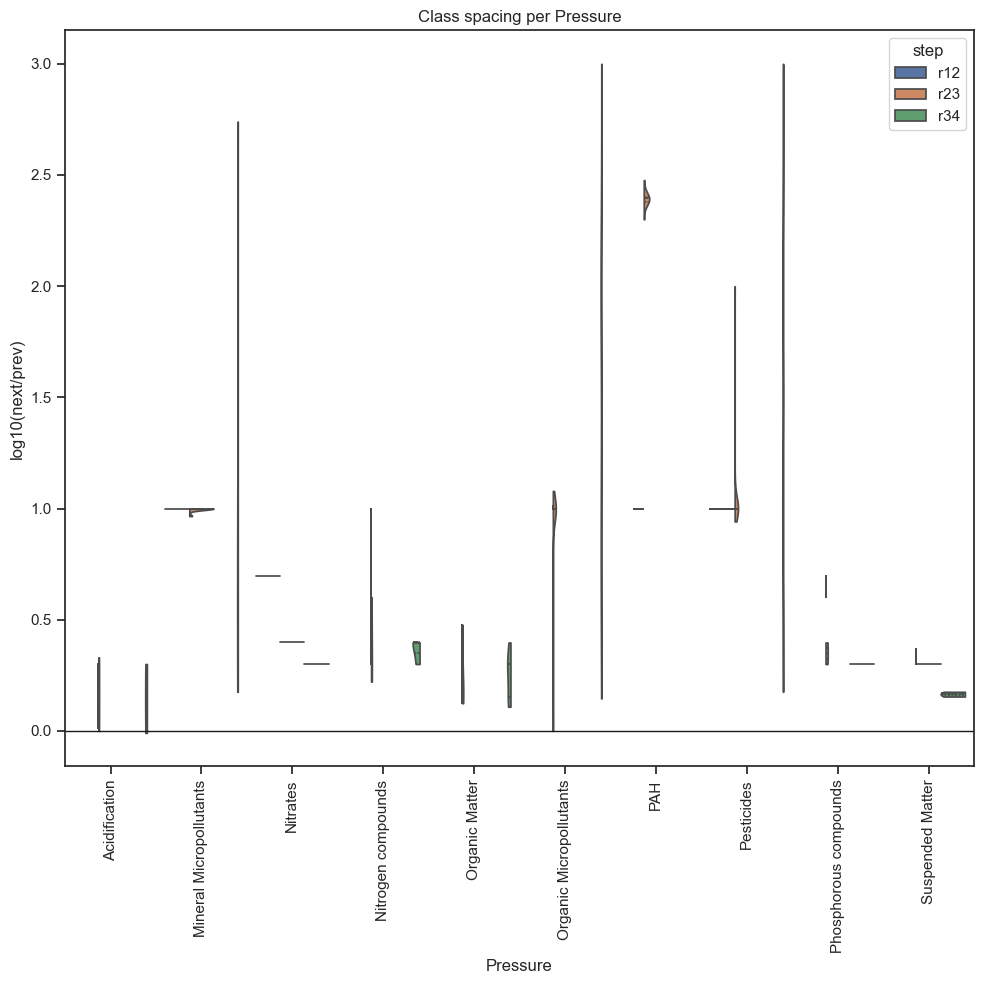

In [35]:
T = (S[['Pressure','r12','r23','r34']]
       .melt('Pressure', var_name='step', value_name='ratio')
       .dropna())
T['log_step'] = np.log10(T['ratio'])
plt.figure(figsize=(10,10))
sns.violinplot(data=T, x='Pressure', y='log_step', hue='step', split=True, inner='quartile', cut=0)
plt.axhline(0, color='k', lw=1)
plt.ylabel('log10(next/prev)'); plt.xticks(rotation=90); plt.title('Class spacing per Pressure')
plt.tight_layout()


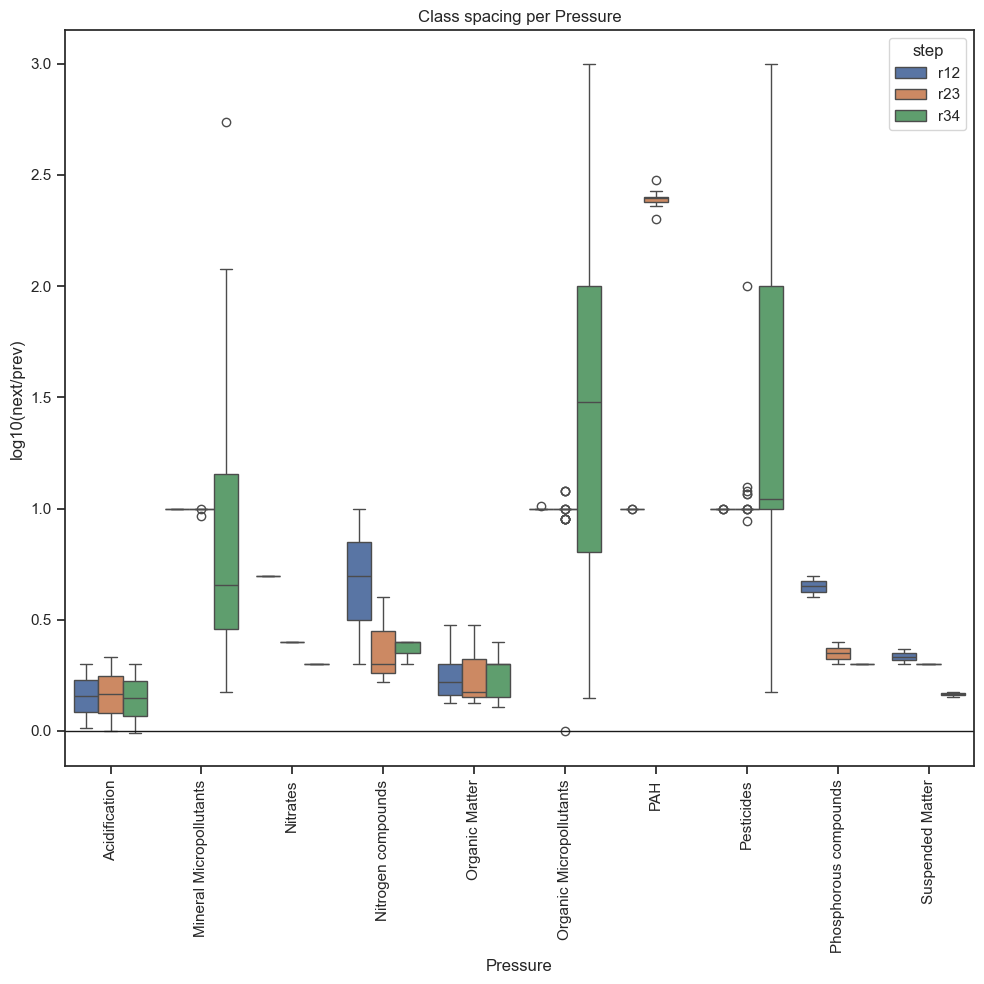

In [34]:
T = (S[['Pressure', 'r12', 'r23', 'r34']]
    .melt('Pressure', var_name='step', value_name='ratio')
    .dropna())
T['log_step'] = np.log10(T['ratio'])
plt.figure(figsize=(10, 10))
sns.boxplot(data=T, x='Pressure', y='log_step', hue='step')
plt.axhline(0, color='k', lw=1)
plt.ylabel('log10(next/prev)')
plt.xticks(rotation=90)
plt.title('Class spacing per Pressure')
plt.tight_layout()


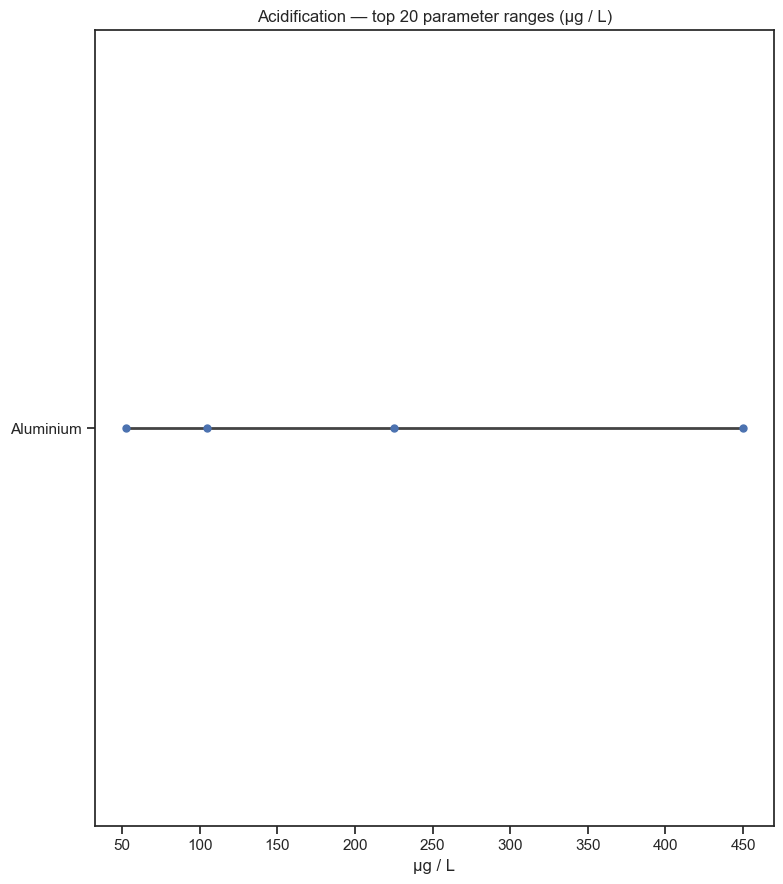

In [18]:
pressure_sel = 'Acidification'   # change
unit_sel     = 'µg / L'          # change
K = 20

sub = (S[(S['Pressure']==pressure_sel)&(S['Unit'].fillna('no unit')==unit_sel)]
         .dropna(subset=['range'])
         .sort_values('range', ascending=False).head(K))
Y = np.arange(len(sub))[::-1]

plt.figure(figsize=(8, 0.4*K+1))
for i, (_, r) in enumerate(sub.iterrows()):
    a = r['asc']; xs = a[np.isfinite(a)]
    plt.plot([xs.min(), xs.max()], [Y[i]]*2, lw=2, color='#444')
    plt.plot(xs, [Y[i]]*len(xs), 'o', ms=5)
plt.yticks(Y, sub['Parameter']); plt.xlabel(unit_sel or 'value')
plt.title(f'{pressure_sel} — top {K} parameter ranges ({unit_sel})')
plt.tight_layout()


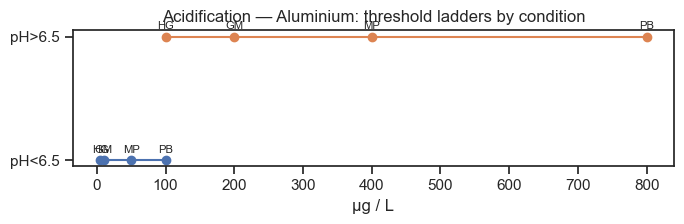

In [19]:
pressure_sel = 'Acidification'   # change
param_sel    = 'Aluminium'       # change

L = (long_notes[(long_notes['Pressure']==pressure_sel) & (long_notes['Parameter']==param_sel)]
       .copy())
order = {'HG':0,'GM':1,'MP':2,'PB':3}
L['x'] = L['bound'].map(order)
unit_here = L['Unit'].dropna().astype(str).mode().iat[0] if not L['Unit'].dropna().empty else 'value'

plt.figure(figsize=(7, 1.2*max(2,L['note'].nunique())))
for j,(note,g) in enumerate(L.groupby('note')):
    g = g.sort_values('x')
    plt.plot(g['thr'], [j]*len(g), '-o')
    for _,row in g.iterrows():
        plt.text(row['thr'], j+0.06, row['bound'], fontsize=8, ha='center')
plt.yticks(range(L['note'].nunique()), [str(n) for n in L['note'].unique()])
plt.xlabel(unit_here); plt.title(f'{pressure_sel} — {param_sel}: threshold ladders by condition')
plt.tight_layout()


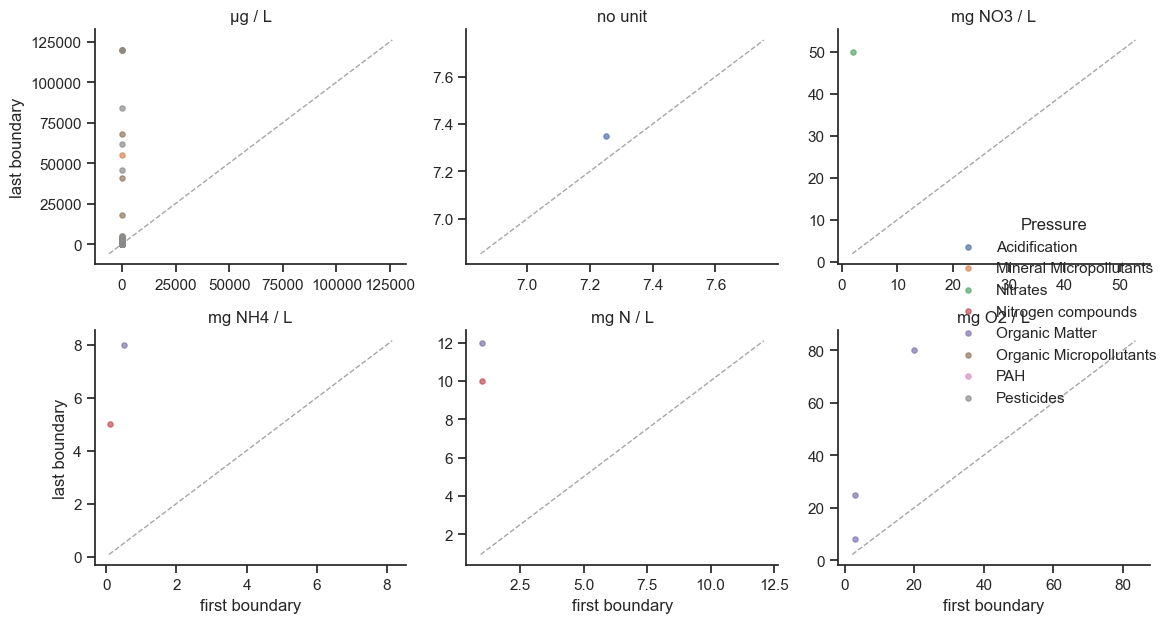

In [20]:
G = S.dropna(subset=['first','last']).copy()
G['Unit'] = G['Unit'].fillna('no unit')

top_units = G['Unit'].value_counts().head(6).index.tolist()
F = G[G['Unit'].isin(top_units)]

g = sns.FacetGrid(F, col='Unit', hue='Pressure', col_wrap=3, height=3.2, sharex=False, sharey=False)
g.map_dataframe(plt.scatter, 'first', 'last', s=14, alpha=0.7)
for ax in g.axes.flat:
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    lo, hi = min(xlim[0], ylim[0]), max(xlim[1], ylim[1])
    ax.plot([lo,hi],[lo,hi], ls='--', lw=1, c='gray', alpha=0.7)
g.add_legend(title='Pressure'); g.set_axis_labels('first boundary','last boundary')
g.set_titles('{col_name}'); plt.tight_layout()


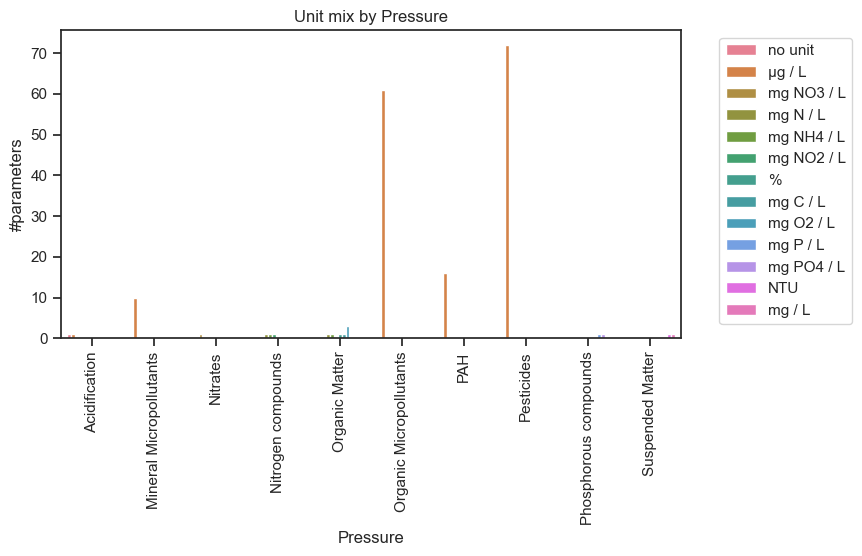

In [30]:
U = (th.assign(Unit=th['Parameter_unit'].fillna('no unit'))
       .groupby(['Pressure','Unit'])['Parameter_label_eng'].nunique()
       .rename('n').reset_index())
plt.figure(figsize=(8,4))
sns.barplot(data=U, x='Pressure', y='n', hue='Unit')
plt.xticks(rotation=90); plt.ylabel('#parameters'); plt.title('Unit mix by Pressure')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
